In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import itertools
import numpy as np

In [2]:
# CONFIGURATION

dataset_old = "trainable_dataset"   
train_dir = os.path.join(dataset_old, "train")
val_dir   = os.path.join(dataset_old, "val")
test_dir  = os.path.join(dataset_old, "test")
image_size = 224
batch_size = 16
num_epochs = 100
learning_rate = 0.0003
weight_decay = 0.05
save_dir = "./vit_with_RPE"
os.makedirs(save_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


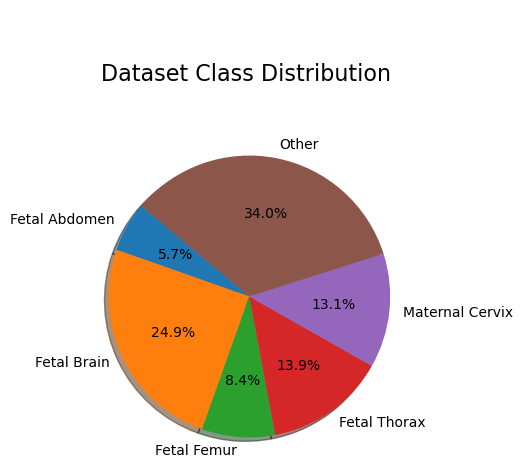

Fetal Abdomen: 568 images
Fetal Brain: 2473 images
Fetal Femur: 832 images
Fetal Thorax: 1374 images
Maternal Cervix: 1300 images
Other: 3370 images


In [3]:
data_dir = train_dir

# Count number of images in each class folder
class_counts = {}
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

# Extract labels and counts
labels = list(class_counts.keys())
sizes = list(class_counts.values())

# Plot pie chart
plt.figure(figsize=(4, 4))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    shadow=True
)
plt.title("\n\nDataset Class Distribution \n\n", fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle.
plt.show()

# Print details
for label, count in class_counts.items():
    print(f"{label}: {count} images")

In [4]:
# DATA PREPROCESSING
#mean = [0.1743, 0.1743, 0.1744]
#std = [0.1701, 0.1701, 0.1702]
train_tfms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    #transforms.Normalize(mean=mean,std=std),
])

val_tfms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=mean,std=std),
])

test_tfms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    #transforms.Normalize(mean=mean,std=std),
])

In [5]:
train_ds = datasets.ImageFolder(train_dir, transform=train_tfms)
val_ds   = datasets.ImageFolder(val_dir, transform=val_tfms)
test_ds  = datasets.ImageFolder(test_dir, transform=val_tfms)

In [6]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4)

num_classes = len(train_ds.classes)
print(f"Classes: {train_ds.classes}")


Classes: ['Fetal Abdomen', 'Fetal Brain', 'Fetal Femur', 'Fetal Thorax', 'Maternal Cervix', 'Other']


In [7]:
class_names = train_ds.classes

In [8]:
print(class_names)

['Fetal Abdomen', 'Fetal Brain', 'Fetal Femur', 'Fetal Thorax', 'Maternal Cervix', 'Other']


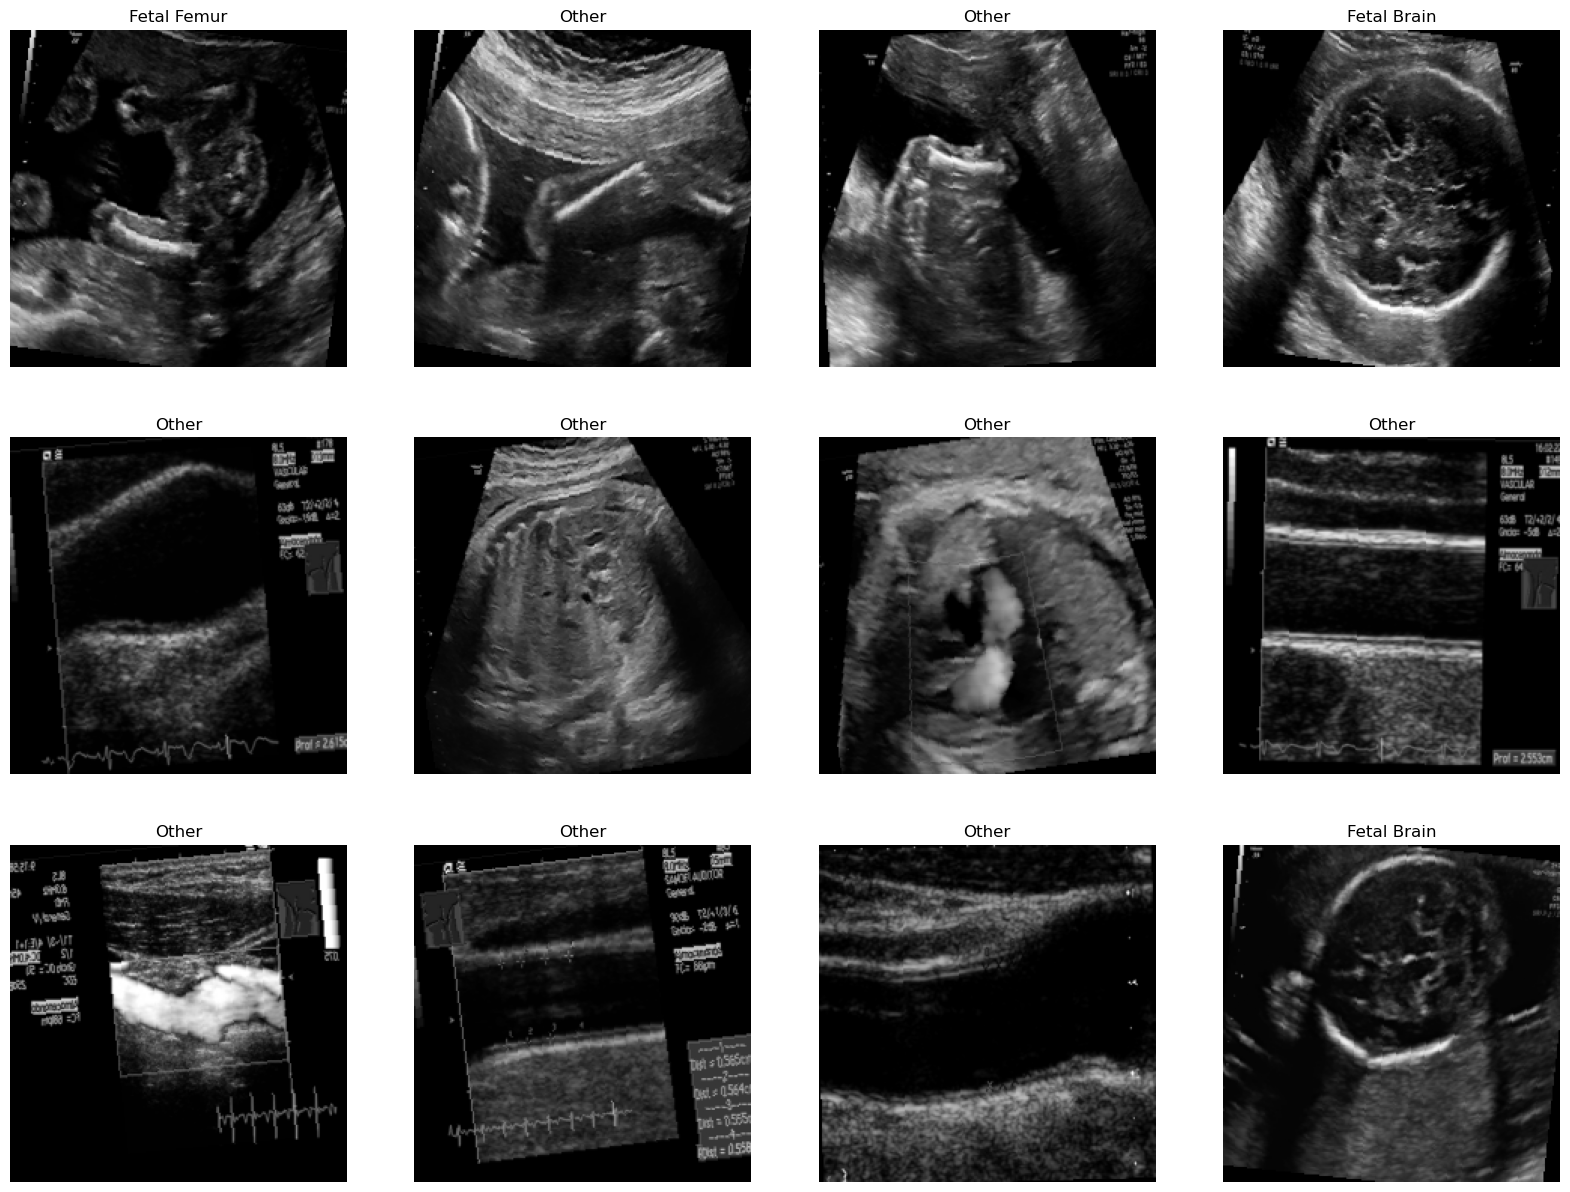

In [9]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Create a figure
plt.figure(figsize=(20, 15))

for i in range(12):
    ax = plt.subplot(3, 4, i + 1)
    
    # Move tensor to CPU and convert to NumPy
    img = images[i].cpu().numpy()
    
    # Transpose image from (C, H, W) to (H, W, C)
    img = img.transpose((1, 2, 0)) 
    plt.imshow(img)
    plt.title(train_ds.classes[labels[i]])
    plt.axis("off")
plt.show()

In [10]:
print(f"numnber of classes is: {num_classes}")
classes = train_ds.classes

numnber of classes is: 6


In [11]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.H = img_size // patch_size
        self.W = img_size // patch_size
        self.num_patches = self.H * self.W

        self.proj = nn.Conv2d(in_chans, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)                          # (B, embed_dim, H/patch, W/patch)
        x = x.flatten(2).transpose(1, 2)          # (B, num_patches, embed_dim)
        return x

In [12]:
# 2. RELATIVE POSITION BIAS (2D)

class RelativePositionBias(nn.Module):
    """
    2D Relative Positional Bias for global attention.
    Works directly with (H*W) patches and cls token.
    """

    def __init__(self, height, width, num_heads):
        super().__init__()

        self.height = height
        self.width = width
        self.num_heads = num_heads

        num_rel = (2 * height - 1) * (2 * width - 1)
        self.relative_bias_table = nn.Parameter(
            torch.zeros(num_rel, num_heads)
        )

        # pairwise relative position indices
        coords_h = torch.arange(height)
        coords_w = torch.arange(width)
        coords = torch.stack(torch.meshgrid(coords_h, coords_w, indexing="ij"))  # (2, H, W)
        coords_flat = coords.reshape(2, -1)                                      # (2, N)

        relative_coords = coords_flat[:, :, None] - coords_flat[:, None, :]      # (2, N, N)
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()          # (N, N, 2)

        relative_coords[:, :, 0] += height - 1
        relative_coords[:, :, 1] += width - 1
        relative_coords[:, :, 0] *= 2 * width - 1

        relative_index = relative_coords.sum(-1)                                 # (N, N)
        self.register_buffer("relative_index", relative_index)

        nn.init.trunc_normal_(self.relative_bias_table, std=0.02)

    def forward(self):
        """
        Returns bias tensor (num_heads, N+1, N+1)
        CLS token is handled with zero bias padding.
        """
        N = self.height * self.width     # number of patches
        bias = self.relative_bias_table[self.relative_index.view(-1)]
        bias = bias.view(N, N, self.num_heads)      # (N, N, H)
        bias = bias.permute(2, 0, 1)                # (H, N, N)

        # Add zeros for CLS token → shape becomes (H, N+1, N+1)
        bias_full = torch.zeros(self.num_heads, N + 1, N + 1, device=bias.device)
        bias_full[:, 1:, 1:] = bias

        return bias_full

In [13]:
# 3. CUSTOM MULTI-HEAD ATTENTION WITH RPE

class MultiHeadAttentionRPE(nn.Module):
    def __init__(self, embed_dim, num_heads, height, width, dropout=0.1):
        super().__init__()

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=True)
        self.proj = nn.Linear(embed_dim, embed_dim)

        self.attention_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

        # relative positional bias
        self.rpb = RelativePositionBias(height, width, num_heads)

    def forward(self, x):
        B, N, C = x.shape

        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        q, k, v = qkv.unbind(dim=2)   # each → (B, N, H, D)

        q = q.transpose(1, 2)         # (B, H, N, D)
        k = k.transpose(1, 2)         # (B, H, N, D)
        v = v.transpose(1, 2)         # (B, H, N, D)

        attn = (q @ k.transpose(-2, -1)) * self.scale

        # add RPE
        rpe = self.rpb()             # (H, N, N)
        attn = attn + rpe.unsqueeze(0)

        attn = attn.softmax(dim=-1)
        attn = self.attention_drop(attn)

        out = attn @ v               # (B, H, N, D)
        out = out.transpose(1, 2).reshape(B, N, C)

        out = self.proj(out)
        out = self.proj_drop(out)
        return out

In [14]:
# 4. TRANSFORMER ENCODER + RPE

class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, height, width, mlp_ratio=4.0, dropout=0.1):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadAttentionRPE(embed_dim, num_heads, height, width, dropout)

        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [15]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3,
                 num_classes=6, embed_dim=256, depth=6, num_heads=8, dropout=0.1):

        super().__init__()

        self.patch_embed = PatchEmbedding(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches
        H = self.patch_embed.H
        W = self.patch_embed.W

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        self.pos_drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, H, W,
                                    mlp_ratio=4.0, dropout=dropout)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)

        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)

        x = self.pos_drop(x)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        cls_out = x[:, 0]
        return self.head(cls_out)

In [16]:
# INITIALIZE MODEL, LOSS, OPTIMIZER

model = VisionTransformer(img_size=image_size, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

In [17]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_acc = 0.0
best_model_path = os.path.join(save_dir, "best_vit.pth")

def evaluate(loader):
    model.eval()
    loss_sum, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss_sum += loss.item() * imgs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    return loss_sum/total, correct/total

for epoch in range(num_epochs):
    model.train()
    total_loss, total_correct, total = 0, 0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

    for imgs, labels in loop:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(1)
        total_loss += loss.item() * imgs.size(0)
        total_correct += (preds == labels).sum().item()
        total += imgs.size(0)
        loop.set_postfix(loss=total_loss/total, acc=total_correct/total)

    train_loss, train_acc = total_loss/total, total_correct/total
    val_loss, val_acc = evaluate(val_loader)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f" Saved best model (val_acc={best_acc:.4f})")

Epoch [1/100]: 100%|████████████████████████████████████████████| 620/620 [01:13<00:00,  8.41it/s, acc=0.39, loss=1.59]


Epoch 1: Train Acc=0.3902, Val Acc=0.4468
Epoch 1: Train Loss=1.5858, Val Loss=1.4883
 Saved best model (val_acc=0.4468)


Epoch [2/100]: 100%|████████████████████████████████████████████| 620/620 [01:08<00:00,  9.02it/s, acc=0.427, loss=1.5]


Epoch 2: Train Acc=0.4273, Val Acc=0.4855
Epoch 2: Train Loss=1.4963, Val Loss=1.3507
 Saved best model (val_acc=0.4855)


Epoch [3/100]: 100%|███████████████████████████████████████████| 620/620 [01:11<00:00,  8.70it/s, acc=0.499, loss=1.31]


...

Epoch 98: Train Acc=0.9643, Val Acc=0.9202
Epoch 98: Train Loss=0.0975, Val Loss=0.2785


Epoch [99/100]: 100%|████████████████████████████████████████| 620/620 [02:18<00:00,  4.47it/s, acc=0.963, loss=0.0994]


Epoch 99: Train Acc=0.9628, Val Acc=0.9202
Epoch 99: Train Loss=0.0994, Val Loss=0.2780


Epoch [100/100]: 100%|███████████████████████████████████████| 620/620 [02:29<00:00,  4.16it/s, acc=0.965, loss=0.0968]


Epoch 100: Train Acc=0.9653, Val Acc=0.9202
Epoch 100: Train Loss=0.0968, Val Loss=0.2781


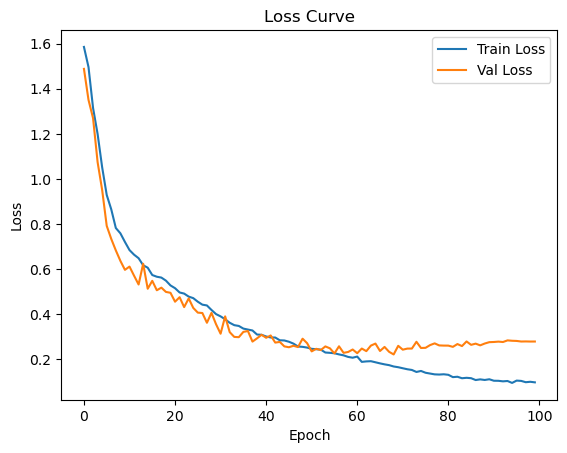

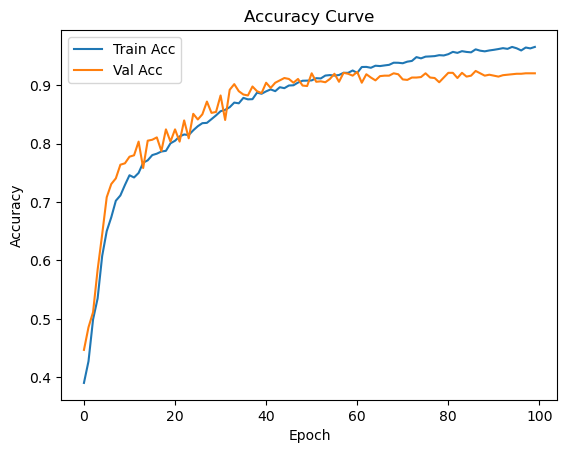

Saved training curves to ./vit_with_RPE


In [ ]:
# PLOT TRAINING CURVES

plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()
"""
plt.savefig(os.path.join(save_dir, "loss_curve.png"))
plt.close()
"""
plt.figure()
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

plt.savefig(os.path.join(save_dir, "acc_curve.png"))
plt.close()
print("Saved training curves to", save_dir)
plt.show()

In [ ]:
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


report = classification_report(all_labels, all_preds, target_names=train_ds.classes, digits=4)
print(report)

Testing: 100%|█████████████████████████████████████████████████████████████████████████| 78/78 [00:24<00:00,  3.18it/s]

                 precision    recall  f1-score   support

  Fetal Abdomen     0.7260    0.7465    0.7361        71
    Fetal Brain     0.9714    0.9871    0.9792       310
    Fetal Femur     0.8713    0.8462    0.8585       104
   Fetal Thorax     0.8971    0.9128    0.9049       172
Maternal Cervix     0.9938    0.9938    0.9938       161
          Other     0.8964    0.8815    0.8889       422

       accuracy                         0.9161      1240
      macro avg     0.8927    0.8946    0.8936      1240
   weighted avg     0.9160    0.9161    0.9160      1240



In [ ]:
with open(os.path.join(save_dir, "classification_report.txt"), "w") as f:
    f.write(report)


In [ ]:
cm = confusion_matrix(all_labels, all_preds)
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', path=None):
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-12)
    plt.figure(figsize=(8,8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha="center", color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

    plt.tight_layout()
    if path:
        plt.savefig(path)
    plt.close()
    plt.show()

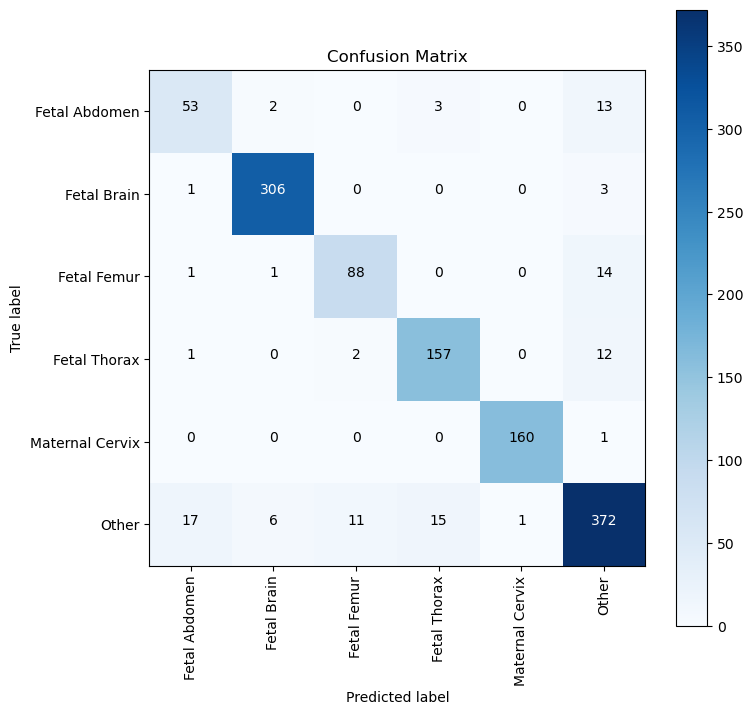

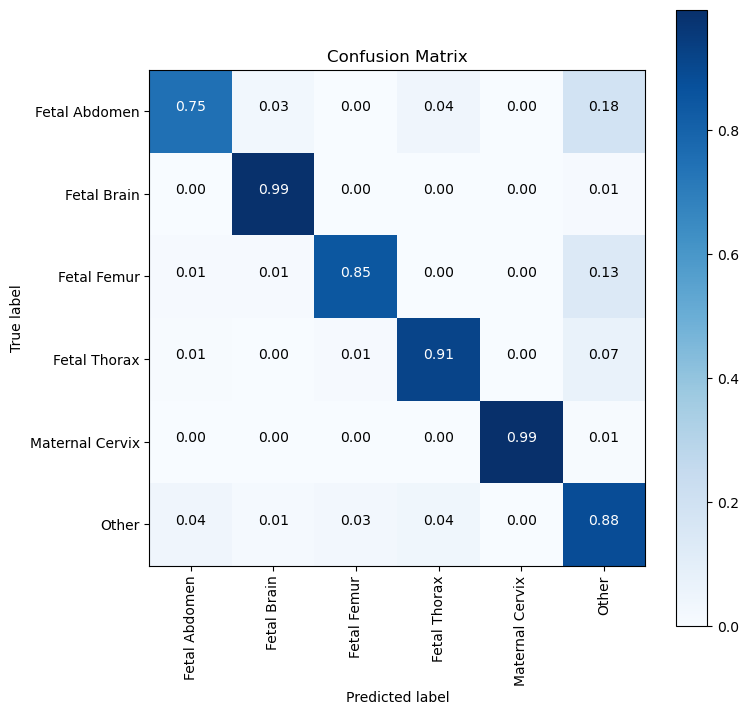

In [ ]:
plot_confusion_matrix(cm, train_ds.classes, normalize=False,
                      path=os.path.join(save_dir, "confusion_matrix.png"))
plot_confusion_matrix(cm, train_ds.classes, normalize=True,
                      path=os.path.join(save_dir, "confusion_matrix_normalized.png"))

In [ ]:
from PIL import Image

In [ ]:
image_path = "trainable_dataset/test/Fetal Thorax/Patient00730_Plane6_6_of_6.png"  # path to your test image
model.to(device)
model.eval()
image = Image.open(image_path).convert('RGB')
input_tensor = test_tfms(image).unsqueeze(0).to(device)

In [ ]:
with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = F.softmax(outputs, dim=1)
    confidence, predicted_class = torch.max(probabilities, 1)
    confidence = confidence.item() * 100
    predicted_class = predicted_class.item()
    
class_names = ['Fetal Abdomen', 'Fetal Brain', 'Fetal Femur', 'Fetal Thorax', 'Maternal Cervix', 'Other']

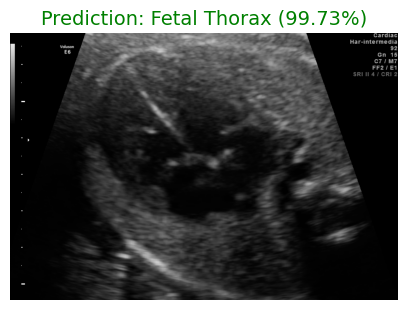

 Predicted Class: Fetal Thorax
 Confidence: 99.73%


In [ ]:
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis('off')
plt.title(f"Prediction: {class_names[predicted_class]} ({confidence:.2f}%)", fontsize=14, color='green')
plt.show()
print(f" Predicted Class: {class_names[predicted_class]}")
print(f" Confidence: {confidence:.2f}%")